# 030. 영화평 Text 분류 - Sentiment Analysis

- IMDB (Internet Movie Database, https://www.imdb.com/)  Dataset


- 각 25,000 개의 training/testing set 으로 구성된 IMDB 영화관람평  


- “imdb_reviews” – encoding 되어있지 않은 string 형태의 data  


- label : positive, negative binary classification

## imbd_reviews (string data) 이용

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout, Bidirectional
from tensorflow.keras.models import Sequential
import tensorflow_datasets as tfds
import numpy as np

In [2]:
tf.__version__

'2.0.0'

In [3]:
dataset, info = tfds.load('imdb_reviews', with_info=True,as_supervised=True)

train_dataset, test_dataset = dataset['train'], dataset['test']

**tfds 는 tf.Tensor 반환**

In [6]:
for input, label in dataset['test']:
    print(label.numpy())
    print()
    print(input.numpy())
    break

1

b'It opens with your cliche overly long ship flying through space. All I could think at this point was "Spaceballs" and hoping there\'d be a sticker on back that said "We break for Nobody." The movie then shows some cryogenic freezers with Vin Diesel\'s narration. I\'ve always thought his voice sounded cool ever since I saw Fast and the Furious. From when I found out he was as criminal, I thought the movie was going to be cliche. It was. It was very cliche and fate seemed to be against them at every turn. Black out every 22 years. Lucky them, they land on that day. Aliens can only be in the darkness, hey it\'s a solar eclipse. As much as I thought it was too easy and just a cliche, the movie pulled through and kicked major @ss. I even went out and bought a copy of Pitch Black after seeing it. I really can\'t wait for Chronicles of Riddick.'


## keras.preprocessing module 을 이용하여 tokenize 및 padding
- keras.preprocessing.text.Tokenizer  

- keras.preprocessing.sequence.pad_sequence

In [7]:
train_sentences = []
train_labels = []

test_sentences = []
test_labels = []

In [8]:
for sent, label in train_dataset:
    train_sentences.append(str(sent.numpy()))
    train_labels.append(label.numpy())

In [12]:
print(train_labels[-1])
print(train_sentences[-1])

0
b"A bad one.<br /><br />Oh, my...this is one of the movies, which doesn't have even one positive effect. Just everything from actors to story stinks to the sky. I just wonder how low I.Q. you should have to watch this kind of flick and even enjoy.<br /><br /> Is there something than this is worth watching for? Well, there is a lot of nudity involved, but it's nothing particular. And when you just think that it couldn't get worse, your realize that all the naked ladies looked like there are forty years old. C'mon guys, where did you search for these actresses. In elderly home, perhaps.<br /><br /> Anyway, the leading actresses has some sex-appeal and knows how to show it. Again, too bad, that she is too skinny & old. All in all, skip these one.<br /><br />2 out of 10"


In [13]:
for sent, label in test_dataset:
    test_sentences.append(str(sent.numpy()))
    test_labels.append(label.numpy())

In [14]:
print(test_labels[-1])
print(test_sentences[-1])

0
b'This movie was disappointing. After 15 years, when it was brought back to mind from reviewing some info about Mariel Hemingway, all the regrets I felt about the movie came rolling back. While I remember Peter O\'Toole, I was entirely oblivious to the fact that the female "lead" (okay, - she was little more than an object for discussion in the storyline) was Ms. Hemingway. I saw this movie back in the days when I wrote movie reviews, and warned people off it, as the stories just didn\'t work, and fifteen years of my subconscious trying to sort things out still hasn\'t made sense of the flow of the ideas.<br /><br />Part of this may have to do with the fact that it looked like, after the original movie (whatever it was about) was filmed, an editor came in and tried to piece together something out of it. I don\'t know if this had been a project of a previous studio boss, and so was sabotaged to discredit him or her by the successor, or this was a disaster from the original screenplay 

## train_labels, test_labels 를 Python list 에서 numpy array 로 변환

In [16]:
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

print(train_labels.shape)
print(test_labels.shape)

(25000,)
(50000,)


## train_sentences, test_sentences text 를 sequence 로 변환 

In [19]:
vocab_size = 10000
max_length = 120

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words = vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(train_sentences)

train_sequences = tokenizer.texts_to_sequences(train_sentences)
train_padded = pad_sequences(train_sequences,maxlen=max_length, truncating='post')

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences,maxlen=max_length, truncating='post')

In [20]:
print(train_padded.shape)
print(test_padded.shape)
print(train_padded[0])

(25000, 120)
(50000, 120)
[   0    0    0    0    0    0    0    0    0    0    0    0  360    7
    4  193 1510  181  104    2 1255  746  202   12  763  372   41  764
   15  249   15  171   30    3   10  306 2635  100   77   60   22  115
  950 1770    1    7  134    2  120  153   45   12  198   19   26    1
    7 7141  181    9   12 3227    2  361   25   31 3915   19   12   60
    2  224 1663  178  181    2  204    7 1555 2510    3    2  115    7
   67 2820  218   37   11  366  785    5  718  930    9  670    6  800
 2193  317    4    1   18  482    2  930   25  169    3  226  199    3
   37   12   20    7 1771   32  120   47]


## sequence data 를 sentence 로 reverse conversion

In [21]:
reverse_word_index = dict([(value, key) for (key, value) in tokenizer.word_index.items()])

def decode_review(text):
    return ' '.join([tokenizer.index_word.get(i, '?') for i in text])
decode_review(train_padded[0])

print(decode_review(train_padded[0]))
print()
print(train_sentences[0])

? ? ? ? ? ? ? ? ? ? ? ? b'this is a big step down after the surprisingly enjoyable original this sequel isn 't nearly as fun as part one and it instead spends too much time on plot development tim <OOV> is still the best thing about this series but his <OOV> is toned down in this entry the performances are all adequate but this time the script lets us down the action is merely routine and the plot is only mildly interesting so i need lots of silly laughs in order to stay entertained during a <OOV> movie unfortunately the laughs are few and far between and so this film is watchable at best '

b'This is a big step down after the surprisingly enjoyable original. This sequel isn\'t nearly as fun as part one, and it instead spends too much time on plot development. Tim Thomerson is still the best thing about this series, but his wisecracking is toned down in this entry. The performances are all adequate, but this time the script lets us down. The action is merely routine and the plot is onl

## model define

In [22]:
model = tf.keras.Sequential([
    Embedding(vocab_size+1, 64),
    Bidirectional(tf.keras.layers.LSTM(64)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, None, 64)          640064    
_________________________________________________________________
bidirectional (Bidirectional (None, 128)               66048     
_________________________________________________________________
dense (Dense)                (None, 64)                8256      
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 65        
Total params: 714,433
Trainable params: 714,433
Non-trainable params: 0
_________________________________________________________________


In [23]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, None, 64)          640064    
_________________________________________________________________
bidirectional (Bidirectional (None, 128)               66048     
_________________________________________________________________
dense (Dense)                (None, 64)                8256      
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 65        
Total params: 714,433
Trainable params: 714,433
Non-trainable params: 0
_________________________________________________________________


In [24]:
num_epochs = 5
history = model.fit(train_padded, train_labels, epochs=num_epochs, batch_size=128,
          validation_data=(test_padded, test_labels), verbose=1)

Train on 25000 samples, validate on 50000 samples
Epoch 1/5
25000/25000 [==============================] - 19s 750us/sample - loss: 0.4728 - accuracy: 0.7538 - val_loss: 0.3881 - val_accuracy: 0.8271
Epoch 2/5
25000/25000 [==============================] - 13s 535us/sample - loss: 0.2861 - accuracy: 0.8844 - val_loss: 0.3924 - val_accuracy: 0.8247
Epoch 3/5
25000/25000 [==============================] - 13s 534us/sample - loss: 0.2292 - accuracy: 0.9115 - val_loss: 0.4252 - val_accuracy: 0.8142
Epoch 4/5
25000/25000 [==============================] - 13s 533us/sample - loss: 0.1812 - accuracy: 0.9339 - val_loss: 0.5086 - val_accuracy: 0.8046
Epoch 5/5
25000/25000 [==============================] - 13s 532us/sample - loss: 0.1237 - accuracy: 0.9562 - val_loss: 0.5738 - val_accuracy: 0.8021


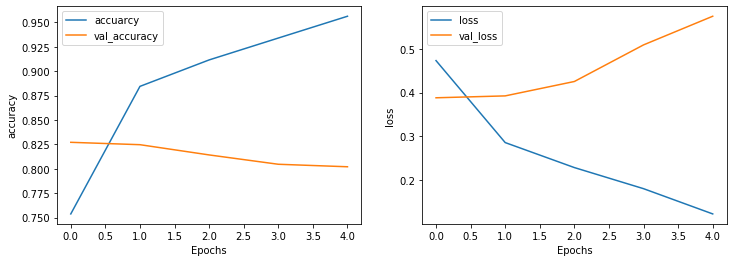

In [25]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.set_xlabel('Epochs')
ax1.set_ylabel('accuracy')
ax1.legend(['accuarcy', 'val_accuracy'])

ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_xlabel('Epochs')
ax2.set_ylabel('loss')
ax2.legend(['loss', 'val_loss'])
plt.show()

In [26]:
sample_text = ['The movei was terrible. I would recommend the movie']
#sample_text = ['The movei was fantastic. I would recommend the movie']
#sample_text = ['The animation and graphics were out of this world']
sample_seq = tokenizer.texts_to_sequences(sample_text)
sample_padded = pad_sequences(sample_seq, maxlen=max_length, truncating='post')
sample_padded

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   2,   1,  14, 401,  11,  64,
        392,   2,  18]])

In [27]:
model.predict([sample_padded])

array([[0.24372312]], dtype=float32)